## Summary:

This notebook visualizes an ablation study to evaluate how different model components impact performance. It compares reconstruction and optimization errors across various model configurations, including the full architecture, linear baselines, and versions with specific loss terms removed, 
to identify which features are critical for accuracy.

## Requirements:

- You need to have generated or saved ham-terms instances 
- You need to have run ablation_study training and optimization
- The ablation study results file needs to be at ```/models/ablation_results_L6/```

In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np
import h5py
from matplotlib.ticker import LogLocator
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FixedLocator

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

# Ablation Results

In [3]:
with open("../models/ablation_results_L6/ablation_summary.json", "r") as f:
    ablation_summary = json.load(f)

model_list = [
    "full_model",
    "reconstruction_only",
    "no_lipschitz",
    "no_well_loss",
    "no_repulsion",
    "linear_model",
]

In [ ]:
optimization_summary = {}

for model in model_list:
    iter_record = []
    for iter in range(5):
        output_path = f"../models/ablation_results_L6/{model}/run_{iter}/optimization_results.hdf5"

        with h5py.File(output_path, "r") as f:
            energy_error_array = np.array(f["energy_error"])
            energy_error_array = energy_error_array[energy_error_array < 1]
            iter_record.append(np.sqrt(np.mean(energy_error_array**2)))

    optimization_summary[model] = {
        "mean": np.mean(iter_record),
        "std": np.std(iter_record),
    }

optimization_summary

{'full_model': {'mean': 0.00035547203, 'std': 7.481845e-05},
 'reconstruction_only': {'mean': 0.08211449, 'std': 0.03376122},
 'no_lipschitz': {'mean': 0.060176123, 'std': 0.023123663},
 'no_well_loss': {'mean': 0.028065646, 'std': 0.0051996075},
 'no_repulsion': {'mean': 0.0004322154, 'std': 3.7796013e-05},
 'linear_model': {'mean': 0.04070228, 'std': 0.0012904811}}

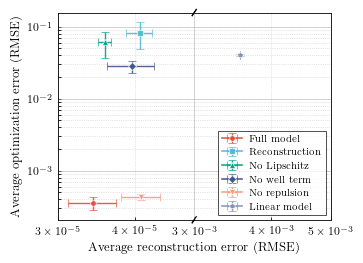

In [5]:
def plot_ablation_scatter(
    model_list, legend_names, ablation_summary, optimization_summary
):
    fig, (ax, ax2) = plt.subplots(
        1, 2, figsize=(3.5, 2.5), sharey=True, gridspec_kw={"wspace": 0.0}
    )

    colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]
    markers = ["o", "s", "^", "D", "v", "p"]

    # 1. Plot Data
    for i, model in enumerate(model_list):
        mean_abl = np.mean(
            np.sqrt(
                ablation_summary[model]["statistics"]["reconstruction_loss"][
                    "all_values"
                ]
            )
        )
        std_abl = np.std(
            np.sqrt(
                ablation_summary[model]["statistics"]["reconstruction_loss"][
                    "all_values"
                ]
            )
        )
        mean_opt = optimization_summary[model]["mean"]
        std_opt = optimization_summary[model]["std"]

        for a in [ax, ax2]:
            a.errorbar(
                mean_abl,
                mean_opt,
                xerr=std_abl,
                yerr=std_opt,
                marker=markers[i],
                markersize=4,
                linewidth=1.2,
                color=colors[i],
                label=legend_names[model],
                markerfacecolor=colors[i],
                markeredgewidth=0.5,
                markeredgecolor="white",
                capsize=3,
                capthick=1,
                elinewidth=1,
                alpha=0.9,
            )

    # 2. Set Log Scales (Must happen before setting ticks)
    for a in [ax, ax2]:
        a.set_xscale("log")
        a.set_yscale("log")

    # 3. Set Limits
    # Adjust these limits slightly if your data falls outside
    ax.set_xlim(3e-5, 5e-5)
    ax2.set_xlim(3e-3, 5e-3)

    # 4. Configure X-Axis Ticks & Grids (The Critical Fix)
    # ---------------------------------------------------
    # Left Subplot X-Axis
    ax.xaxis.set_major_locator(FixedLocator([3e-5, 5e-5]))
    # Re-apply LogLocator for minors so grid lines appear between your fixed ticks
    ax.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(1, 10) * 0.1, numticks=100)
    )

    # Right Subplot X-Axis
    ax2.xaxis.set_major_locator(FixedLocator([3e-3, 5e-3]))
    ax2.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(1, 10) * 0.1, numticks=100)
    )

    # 5. Configure Y-Axis Ticks & Grids (The Trick for ax2)
    # -----------------------------------------------------
    # Ensure major ticks are standard log
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
    ax.yaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100)
    )

    # Apply standard formatting
    for a in [ax, ax2]:
        # Draw the grids explicitly
        a.grid(
            True, which="major", linestyle="-", alpha=0.5, color="gray", linewidth=0.5
        )
        a.grid(
            True, which="minor", linestyle=":", alpha=0.4, color="gray", linewidth=0.5
        )

        # Standard tick params (inward ticks)
        a.tick_params(direction="in", which="both")

    # 6. Hide ax2 Y-ticks specifically
    # length=0 hides the black mark, labelleft=False hides numbers, but Grid remains because locator is valid
    ax2.tick_params(axis="y", which="both", length=0, labelleft=False)

    # 7. Cosmetics (Spines and Labels)
    ax.set_xlabel("Average reconstruction error (RMSE)", fontsize=9, x=1)
    ax.set_ylabel("Average optimization error (RMSE)", fontsize=9)

    ax.spines["right"].set_visible(False)
    ax2.spines["left"].set_visible(False)

    # Break marks
    d = 0.015
    kwargs = dict(transform=ax.transAxes, color="k", clip_on=False, linewidth=0.8)
    ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)
    ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
    kwargs.update(transform=ax2.transAxes)
    ax2.plot((-d, +d), (-d, +d), **kwargs)
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

    # Legend
    legend = ax2.legend(
        frameon=True, loc="lower right", fontsize=7, fancybox=False, edgecolor="black"
    )
    legend.get_frame().set_linewidth(0.6)

    labels = ax.get_xticklabels()
    if len(labels) > 0:
        labels[-1].set_visible(False)

    # Hide the first one on ax2
    # labels2 = ax2.get_xticklabels()
    # if len(labels2) > 0:
    #     labels2[0].set_visible(False)

    fig.tight_layout(pad=0.3)
    return fig


legend_names = {
    "full_model": "Full model",
    "reconstruction_only": "Reconstruction",
    "no_lipschitz": "No Lipschitz",
    "no_well_loss": "No well term",
    "no_repulsion": "No repulsion",
    "linear_model": "Linear model",
}


fig = plot_ablation_scatter(
    model_list, legend_names, ablation_summary, optimization_summary
)

# fig.savefig("ablation.pdf", dpi=300, bbox_inches="tight")